In [ ]:
!nvidia-smi

Mon Feb 16 02:32:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q transformers accelerate bitsandbytes torch torchvision pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 17.5 MB/s eta 0:00:00


In [ ]:
import torch
from PIL import Image
from transformers import AutoProcessor, LlavaForConditionalGeneration

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model_id = "llava-hf/llava-1.5-7b-hf"

processor = AutoProcessor.from_pretrained(model_id)

model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

Saving heidi-image.jpg to heidi-image (2).jpg


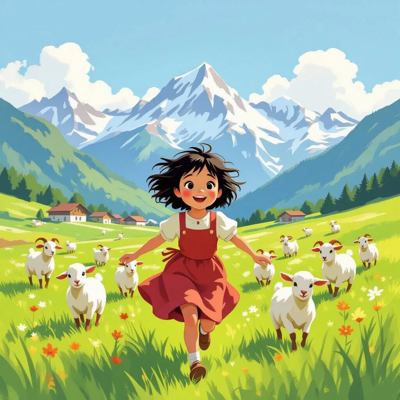

In [ ]:
# Upload image
from google.colab import files
uploaded = files.upload()
image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")
display(image.resize((400, 400)))


In [ ]:
prompt = """USER: <image>
You are a cinematic storyteller.
Write a rich, detailed, emotionally immersive multi-paragraph narrative
based on this image. Describe atmosphere, lighting, emotions,
subtle details, and possible backstory.
ASSISTANT:"""

inputs = processor(text=prompt, images=image, return_tensors="pt")

inputs = {k: v.to(device) for k, v in inputs.items()}

output = model.generate(
    **inputs,
    max_new_tokens=400,
    temperature=0.9,
    top_p=0.95,
    do_sample=True
)

output_text = processor.decode(output[0], skip_special_tokens=True)
message = output_text.split("ASSISTANT:")[-1].strip()


In [ ]:
import textwrap

wrapped_text = textwrap.fill(message, width=100)
print(wrapped_text)

In the image, a small girl with long black hair, wearing a red dress, is joyfully running through a
lush green field filled with dozens of baby sheep, also known as lambs. She is surrounded by vibrant
yellow wildflowers, giving the scene a sense of warmth and playfulness. The setting is a beautiful
alpine valley with majestic mountains in the background. The sun is shining brightly, casting a
gentle glow over the landscape and highlighting the soft, fluffy coats of the lambs.  The girl's
laughter can be heard as she runs, seemingly free and carefree, a perfect embodiment of childhood
innocence and happiness. Her attire and action suggest a sense of freedom and the sheer pleasure of
being outdoors in a picturesque, tranquil setting. The scene seems to evoke feelings of wonder,
curiosity, and the simple joys of life, offering a glimpse into the life of the little girl and the
animals around her.
